# Laboratorio 4 — Cuaderno 5: correlaciones y comparación entre lagos

**Ejercicios 6 y 7.** Relación del índice de cianobacteria con NDVI y NDWI, y comparación de
fondo entre Atitlán y Amatitlán.

In [1]:
import sys
from pathlib import Path

if str(Path.cwd()) not in sys.path:
    sys.path.insert(0, str(Path.cwd()))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

from src import config, datos, graficos
from src import indices as ix

resumen = datos.tabla_resumen()
COLOR = {"Atitlan": "#1f6f8b", "Amatitlan": "#c1272d"}
print(f"{len(resumen)} escenas cargadas")

22 escenas cargadas


## 6. Correlación de NDVI y NDWI con la cianobacteria

Hacemos el análisis en dos niveles, porque responden preguntas distintas:

- **Nivel de píxel:** dentro de una misma imagen, ¿los puntos del lago con más cianobacteria son
  también los que tienen NDVI más alto? Esto dice si los índices detectan la misma cosa
  físicamente.
- **Nivel de escena:** entre fechas, ¿los días con lago más cargado son los que tienen NDVI más
  alto en promedio? Esto dice si sirven como señal de alerta a escala de todo el lago.

Usamos correlación de **Pearson** (relación lineal) y de **Spearman** (relación monótona, sin
suponer que sea recta). Spearman es más robusta cuando la relación existe pero es curva, que es
lo esperable aquí.

### 6.1 Correlación a nivel de píxel

Tomamos una muestra aleatoria de píxeles de agua de cada escena. Se submuestrea porque un lago
tiene cientos de miles de píxeles y para estimar una correlación no hacen falta todos.

In [2]:
pixeles = datos.tabla_pixeles(recalcular=True)
print(f"{len(pixeles):,} píxeles muestreados")
pixeles.head()

440,000 píxeles muestreados


,lago,fecha,chl,ndci,ndvi,ndwi,fai
0,Atitlan,2025-01-18,0.377011,-0.089325,-0.160093,0.461309,0.001089
1,Atitlan,2025-01-18,1.404921,-0.073298,-0.253823,0.551471,0.000059
2,Atitlan,2025-01-18,0.098603,-0.093199,-0.284024,0.565530,-0.000846
3,Atitlan,2025-01-18,0.000000,-0.115789,-0.308642,0.590494,-0.000869
4,Atitlan,2025-01-18,0.264615,-0.090909,-0.292308,0.582577,-0.000205


In [3]:
filas = []
for lago in ["Atitlan", "Amatitlan"]:
    sub = pixeles[pixeles["lago"] == lago].dropna(subset=["chl", "ndvi", "ndwi"])
    for indice in ["ndvi", "ndwi", "fai"]:
        r_p, p_p = stats.pearsonr(sub[indice], sub["chl"])
        r_s, p_s = stats.spearmanr(sub[indice], sub["chl"])
        filas.append({
            "lago": config.NOMBRE_LARGO[lago],
            "indice": indice.upper(),
            "n_pixeles": len(sub),
            "pearson_r": round(r_p, 3),
            "spearman_r": round(r_s, 3),
            "p_valor": f"{max(p_p, p_s):.1e}",
        })

correlaciones_pixel = pd.DataFrame(filas)
correlaciones_pixel

,lago,indice,n_pixeles,pearson_r,spearman_r,p_valor
0,Lago de Atitlán,NDVI,220000,0.697,0.713,0.0e+00
1,Lago de Atitlán,NDWI,220000,-0.683,-0.703,0.0e+00
2,Lago de Atitlán,FAI,220000,0.453,0.304,0.0e+00
3,Lago de Amatitlán,NDVI,220000,0.760,0.659,0.0e+00
4,Lago de Amatitlán,NDWI,220000,-0.620,-0.470,0.0e+00
5,Lago de Amatitlán,FAI,220000,0.883,0.844,0.0e+00


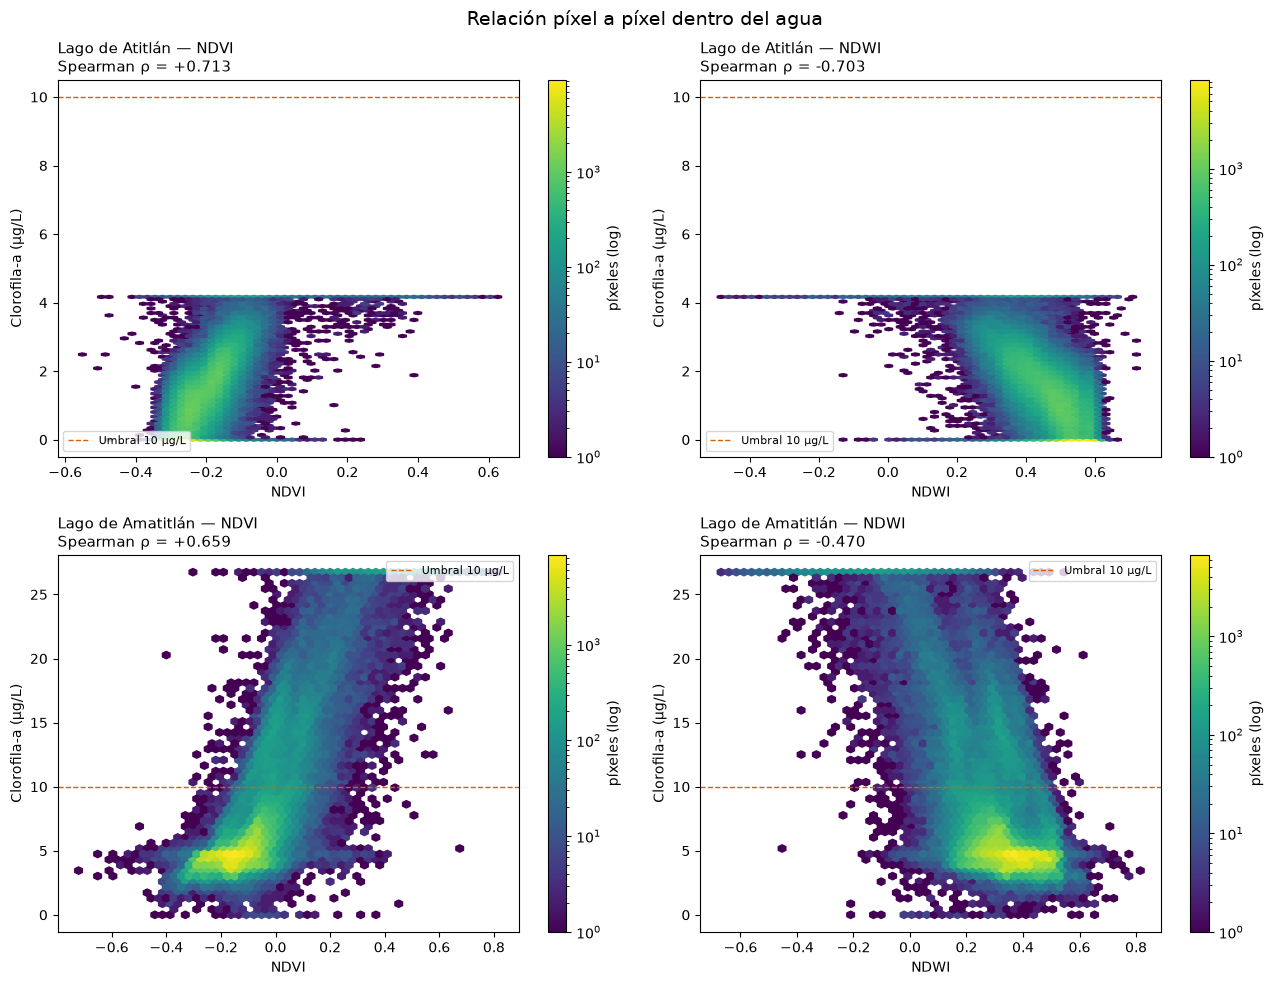

In [4]:
fig, ejes = plt.subplots(2, 2, figsize=(13, 10))

for fila, lago in enumerate(["Atitlan", "Amatitlan"]):
    sub = pixeles[pixeles["lago"] == lago].dropna(subset=["chl", "ndvi", "ndwi"])
    # Se recorta el eje de clorofila al percentil 99 para que unos pocos
    # píxeles extremos no aplasten toda la nube de puntos.
    tope = np.percentile(sub["chl"], 99)

    for columna, indice in enumerate(["ndvi", "ndwi"]):
        eje = ejes[fila, columna]
        h = eje.hexbin(sub[indice], sub["chl"].clip(upper=tope),
                       gridsize=55, cmap="viridis", bins="log", mincnt=1)
        r_s, _ = stats.spearmanr(sub[indice], sub["chl"])
        eje.set_title(f"{config.NOMBRE_LARGO[lago]} — {indice.upper()}\n"
                      f"Spearman ρ = {r_s:+.3f}", fontsize=11, loc="left")
        eje.set_xlabel(indice.upper())
        eje.set_ylabel("Clorofila-a (µg/L)")
        eje.axhline(ix.UMBRAL_ALTO_CHL, color="#d95f02", linestyle="--",
                    linewidth=1, label=f"Umbral {ix.UMBRAL_ALTO_CHL:.0f} µg/L")
        eje.legend(fontsize=8)
        plt.colorbar(h, ax=eje, label="píxeles (log)")

fig.suptitle("Relación píxel a píxel dentro del agua", fontsize=14)
fig.tight_layout()
plt.show()

### 6.2 Correlación a nivel de escena

Ahora un punto por fecha: el promedio del lago de cada índice contra el promedio de clorofila.
Con 11 fechas por lago la potencia estadística es baja, así que reportamos el valor p y lo
tomamos como indicio, no como prueba.

In [5]:
filas = []
for lago in ["Atitlan", "Amatitlan"]:
    sub = resumen[resumen["lago"] == lago].dropna(subset=["chl_media", "ndvi_media", "ndwi_media"])
    for indice in ["ndvi_media", "ndwi_media", "ndci_media"]:
        r_p, p_p = stats.pearsonr(sub[indice], sub["chl_media"])
        r_s, p_s = stats.spearmanr(sub[indice], sub["chl_media"])
        filas.append({
            "lago": config.NOMBRE_LARGO[lago],
            "indice": indice.replace("_media", "").upper(),
            "n_fechas": len(sub),
            "pearson_r": round(r_p, 3),
            "p_pearson": round(p_p, 4),
            "spearman_r": round(r_s, 3),
            "significativo_5pct": "sí" if p_p < 0.05 else "no",
        })

correlaciones_escena = pd.DataFrame(filas)
correlaciones_escena

,lago,indice,n_fechas,pearson_r,p_pearson,spearman_r,significativo_5pct
0,Lago de Atitlán,NDVI,11,0.897,0.0002,0.918,sí
1,Lago de Atitlán,NDWI,11,-0.955,0.0000,-0.955,sí
2,Lago de Atitlán,NDCI,11,0.999,0.0000,1.000,sí
3,Lago de Amatitlán,NDVI,11,0.740,0.0092,0.745,sí
4,Lago de Amatitlán,NDWI,11,-0.348,0.2937,-0.236,no
5,Lago de Amatitlán,NDCI,11,0.909,0.0001,0.927,sí


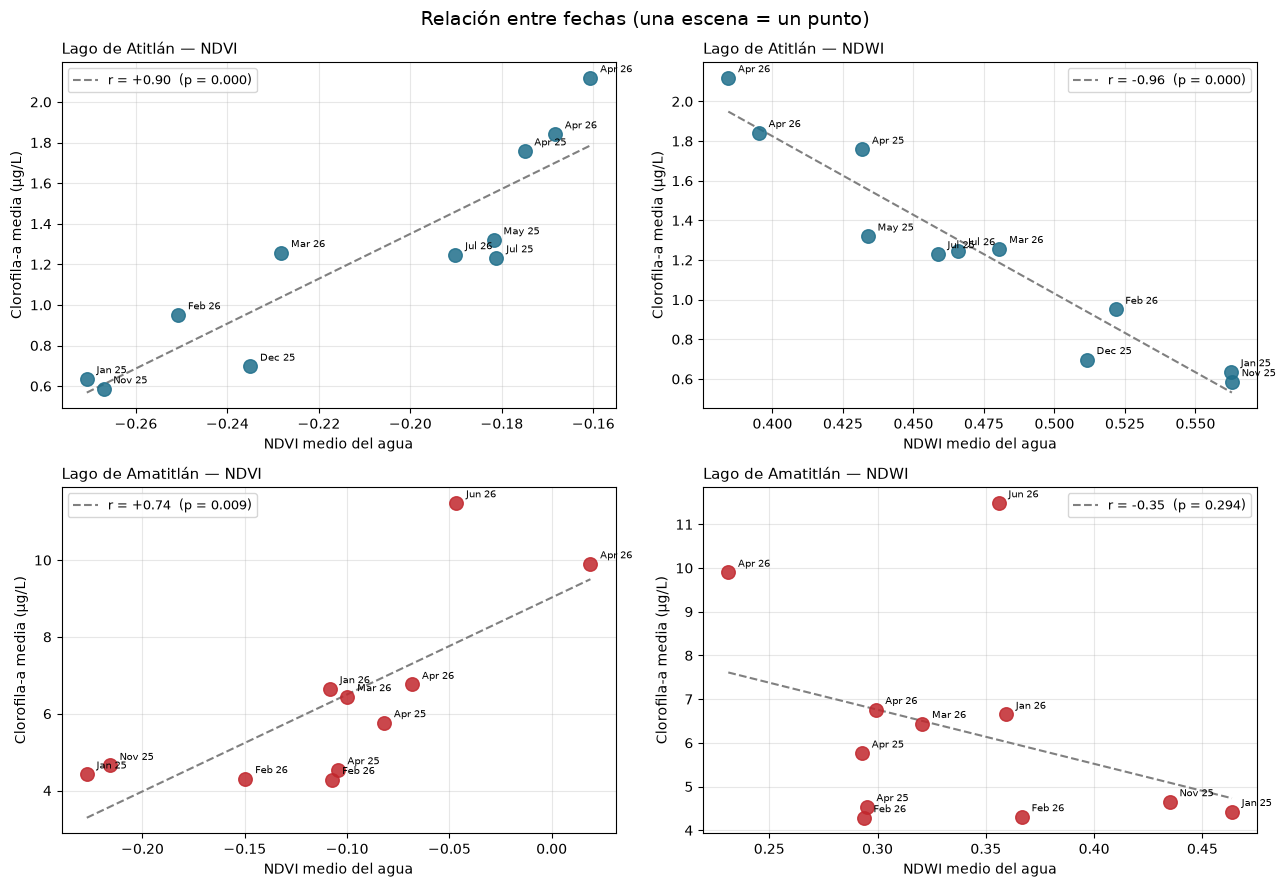

In [6]:
fig, ejes = plt.subplots(2, 2, figsize=(13, 9))

for fila, lago in enumerate(["Atitlan", "Amatitlan"]):
    sub = resumen[resumen["lago"] == lago].dropna(subset=["chl_media"])
    for columna, indice in enumerate(["ndvi_media", "ndwi_media"]):
        eje = ejes[fila, columna]
        eje.scatter(sub[indice], sub["chl_media"], s=95, color=COLOR[lago],
                    alpha=0.85, zorder=3)
        for _, f in sub.iterrows():
            eje.annotate(f"{f['fecha']:%b %y}", (f[indice], f["chl_media"]),
                         textcoords="offset points", xytext=(7, 4), fontsize=7)

        if len(sub) > 2:
            pendiente, corte, r, p, _ = stats.linregress(sub[indice], sub["chl_media"])
            xs = np.linspace(sub[indice].min(), sub[indice].max(), 50)
            eje.plot(xs, pendiente * xs + corte, "--", color="gray", linewidth=1.5,
                     label=f"r = {r:+.2f}  (p = {p:.3f})", zorder=2)
            eje.legend(fontsize=9)

        eje.set_title(f"{config.NOMBRE_LARGO[lago]} — {indice.replace('_media','').upper()}",
                      fontsize=11, loc="left")
        eje.set_xlabel(f"{indice.replace('_media','').upper()} medio del agua")
        eje.set_ylabel("Clorofila-a media (µg/L)")
        eje.grid(alpha=0.3)

fig.suptitle("Relación entre fechas (una escena = un punto)", fontsize=14)
fig.tight_layout()
plt.show()

### 6.3 Por qué la relación tiene el signo que tiene

Vale la pena entender la física antes de leer los números, porque hay una parte del resultado
que está garantizada por construcción y otra que sí es informativa.

**NDVI y clorofila comparten la banda roja (B04).** El NDVI la resta en el numerador y el NDCI
también. Cuando hay más clorofila, la banda roja baja (la clorofila la absorbe), y eso empuja
los dos índices hacia arriba a la vez. Por eso una correlación positiva entre NDVI y clorofila
*dentro del agua* es en buena parte esperable, y no debe leerse como un descubrimiento
independiente: es la misma señal vista de dos maneras.

**NDWI se mueve al revés.** El NDWI compara verde contra infrarrojo cercano. Un agua con
floración densa refleja más en el infrarrojo —empieza a comportarse ópticamente como
vegetación— así que el denominador crece y el NDWI baja. Una correlación negativa entre NDWI y
clorofila es la firma de que el agua está perdiendo su comportamiento óptico de agua limpia.

Lo genuinamente informativo es la **magnitud** y el **contraste entre los dos lagos**: si en un
lago la relación es fuerte y en el otro es débil, eso dice algo sobre qué tan dominada está la
señal óptica del agua por el fitoplancton frente a otras cosas (sedimento en suspensión,
profundidad, materia orgánica disuelta).

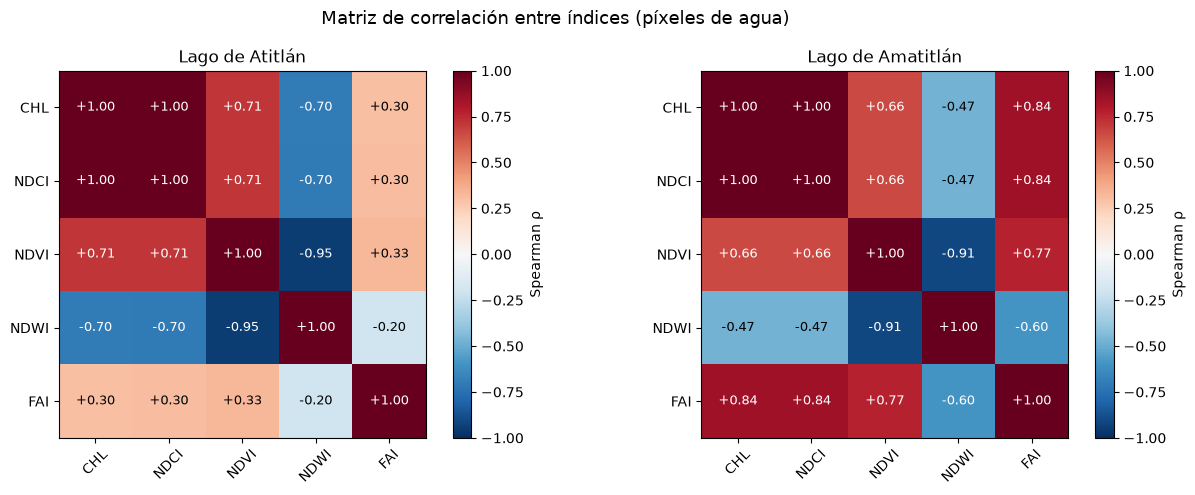

In [7]:
# El sedimento en suspensión es el principal competidor de la clorofila como
# explicación de la señal. Un agua cargada de sedimento se ve brillante en el
# rojo, justo al revés que un agua cargada de algas.
filas = []
for lago in ["Atitlan", "Amatitlan"]:
    sub = pixeles[pixeles["lago"] == lago].dropna(subset=["chl", "ndci", "ndvi", "ndwi", "fai"])
    matriz = sub[["chl", "ndci", "ndvi", "ndwi", "fai"]].corr(method="spearman")
    filas.append((lago, matriz))

fig, ejes = plt.subplots(1, 2, figsize=(13, 5))
for eje, (lago, matriz) in zip(ejes, filas):
    im = eje.imshow(matriz, cmap="RdBu_r", vmin=-1, vmax=1)
    eje.set_xticks(range(len(matriz)), [c.upper() for c in matriz.columns], rotation=45)
    eje.set_yticks(range(len(matriz)), [c.upper() for c in matriz.columns])
    for i in range(len(matriz)):
        for j in range(len(matriz)):
            eje.text(j, i, f"{matriz.iloc[i, j]:+.2f}", ha="center", va="center",
                     fontsize=9,
                     color="white" if abs(matriz.iloc[i, j]) > 0.55 else "black")
    eje.set_title(config.NOMBRE_LARGO[lago], fontsize=12)
    plt.colorbar(im, ax=eje, fraction=0.046, label="Spearman ρ")

fig.suptitle("Matriz de correlación entre índices (píxeles de agua)", fontsize=13)
fig.tight_layout()
plt.show()

## 7. Comparación entre los dos lagos

### 7.1 Intensidad de la floración

In [8]:
comparacion = resumen.groupby("lago").agg(
    escenas=("chl_media", "size"),
    chl_media_periodo=("chl_media", "mean"),
    chl_mediana_periodo=("chl_mediana", "median"),
    chl_min=("chl_media", "min"),
    chl_max=("chl_media", "max"),
    chl_pico_absoluto=("chl_max", "max"),
    desviacion=("chl_media", "std"),
    pct_alto_medio=("pct_alto", "mean"),
    pct_alto_max=("pct_alto", "max"),
    area_km2=("area_agua_km2", "median"),
).round(2)

comparacion["coef_variacion"] = (comparacion["desviacion"] /
                                 comparacion["chl_media_periodo"]).round(3)
comparacion.index = [config.NOMBRE_LARGO[i] for i in comparacion.index]
comparacion.T

,Lago de Amatitlán,Lago de Atitlán
escenas,11.000,11.000
chl_media_periodo,6.290,1.240
chl_mediana_periodo,4.870,1.120
chl_min,4.290,0.590
chl_max,11.490,2.120
chl_pico_absoluto,130.120,135.860
desviacion,2.410,0.510
pct_alto_medio,10.800,0.040
pct_alto_max,53.390,0.140
area_km2,14.660,122.130


In [9]:
razon = (comparacion["chl_media_periodo"]["Lago de Amatitlán"] /
         comparacion["chl_media_periodo"]["Lago de Atitlán"])
print(f"Amatitlán tiene en promedio {razon:.1f} veces la concentración de Atitlán.")
print(f"Amatitlán es {comparacion['area_km2']['Lago de Atitlán'] / comparacion['area_km2']['Lago de Amatitlán']:.1f} "
      f"veces más pequeño en superficie.")

Amatitlán tiene en promedio 5.1 veces la concentración de Atitlán.
Amatitlán es 8.3 veces más pequeño en superficie.


### 7.2 Frecuencia de floraciones

Contamos en cuántas de las 11 fechas cada lago cruzó distintos niveles de severidad. La
intensidad dice qué tan mal se pone; la frecuencia dice qué tan seguido.

In [10]:
NIVELES = [
    ("Mesotrófico", 2.6, "productividad moderada"),
    ("Eutrófico", 7.3, "floraciones frecuentes"),
    ("Vigilancia OMS", 10, "riesgo recreativo bajo"),
    ("Alerta OMS", 50, "riesgo recreativo alto"),
]

filas = []
for lago in ["Atitlan", "Amatitlan"]:
    sub = resumen[resumen["lago"] == lago]
    fila = {"lago": config.NOMBRE_LARGO[lago], "escenas": len(sub)}
    for nombre, corte, _ in NIVELES:
        n = int((sub["chl_media"] > corte).sum())
        fila[f"{nombre} (>{corte:g})"] = f"{n}/{len(sub)}  ({100*n/len(sub):.0f}%)"
    filas.append(fila)

frecuencias = pd.DataFrame(filas).set_index("lago")
frecuencias.T

lago,Lago de Atitlán,Lago de Amatitlán
escenas,11,11
Mesotrófico (>2.6),0/11 (0%),11/11 (100%)
Eutrófico (>7.3),0/11 (0%),2/11 (18%)
Vigilancia OMS (>10),0/11 (0%),1/11 (9%)
Alerta OMS (>50),0/11 (0%),0/11 (0%)


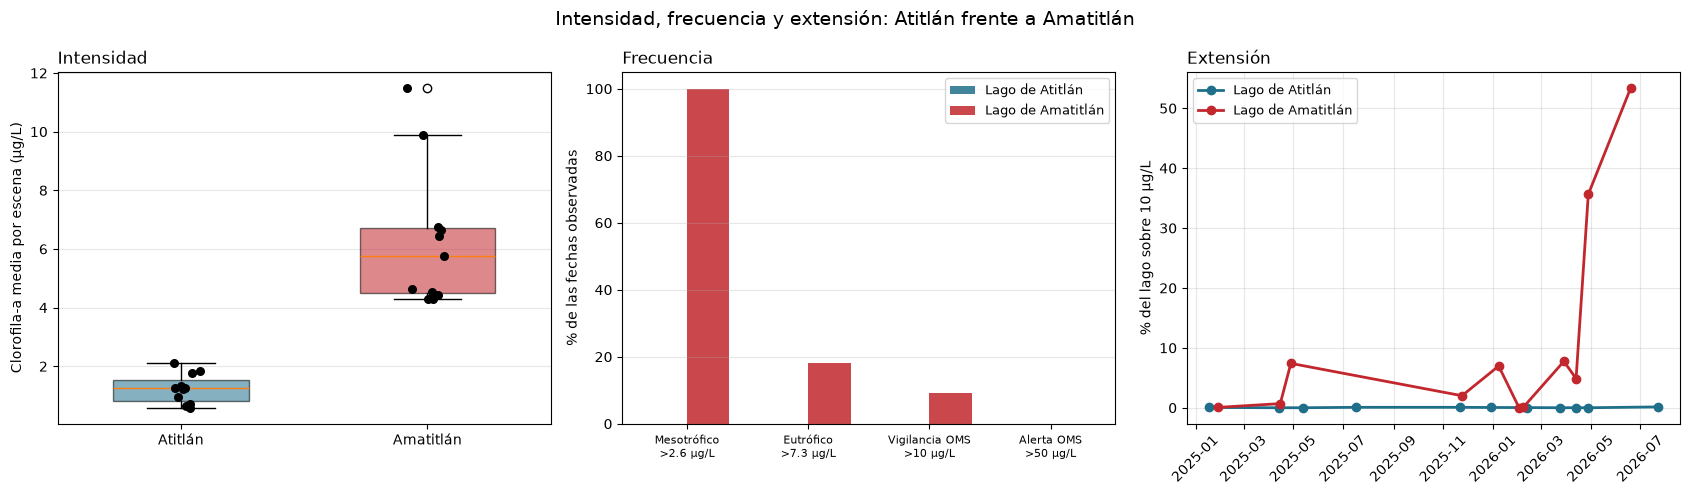

In [11]:
fig, ejes = plt.subplots(1, 3, figsize=(17, 5))

# Panel 1: distribución de las medias por escena
datos_caja = [resumen[resumen["lago"] == l]["chl_media"].dropna().values
              for l in ["Atitlan", "Amatitlan"]]
partes = ejes[0].boxplot(datos_caja, tick_labels=["Atitlán", "Amatitlán"],
                         patch_artist=True, widths=0.55)
for caja, lago in zip(partes["boxes"], ["Atitlan", "Amatitlan"]):
    caja.set_facecolor(COLOR[lago]); caja.set_alpha(0.55)
for i, g in enumerate(datos_caja, start=1):
    ejes[0].scatter(np.random.normal(i, 0.05, len(g)), g, color="black", s=30, zorder=3)
ejes[0].set_ylabel("Clorofila-a media por escena (µg/L)")
ejes[0].set_title("Intensidad", loc="left", fontsize=12)
ejes[0].grid(alpha=0.3, axis="y")

# Panel 2: frecuencia de superación de umbrales
ancho = 0.35
posiciones = np.arange(len(NIVELES))
for k, lago in enumerate(["Atitlan", "Amatitlan"]):
    sub = resumen[resumen["lago"] == lago]
    alturas = [100 * (sub["chl_media"] > corte).mean() for _, corte, _ in NIVELES]
    ejes[1].bar(posiciones + (k - 0.5) * ancho, alturas, ancho,
                color=COLOR[lago], alpha=0.85, label=config.NOMBRE_LARGO[lago])
ejes[1].set_xticks(posiciones,
                   [f"{n}\n>{c:g} µg/L" for n, c, _ in NIVELES], fontsize=8)
ejes[1].set_ylabel("% de las fechas observadas")
ejes[1].set_title("Frecuencia", loc="left", fontsize=12)
ejes[1].legend(fontsize=9)
ejes[1].grid(alpha=0.3, axis="y")

# Panel 3: extensión de la floración
for lago in ["Atitlan", "Amatitlan"]:
    sub = resumen[resumen["lago"] == lago].sort_values("fecha")
    ejes[2].plot(sub["fecha"], sub["pct_alto"], "o-", color=COLOR[lago],
                 label=config.NOMBRE_LARGO[lago], linewidth=2)
ejes[2].set_ylabel(f"% del lago sobre {ix.UMBRAL_ALTO_CHL:.0f} µg/L")
ejes[2].set_title("Extensión", loc="left", fontsize=12)
ejes[2].legend(fontsize=9)
ejes[2].tick_params(axis="x", rotation=45)
ejes[2].grid(alpha=0.3)

fig.suptitle("Intensidad, frecuencia y extensión: Atitlán frente a Amatitlán", fontsize=14)
fig.tight_layout()
plt.show()

### 7.3 Distribución completa de valores

Los promedios comparan mal cuando las distribuciones tienen formas distintas. Aquí está la
distribución completa de los píxeles de agua de cada lago.

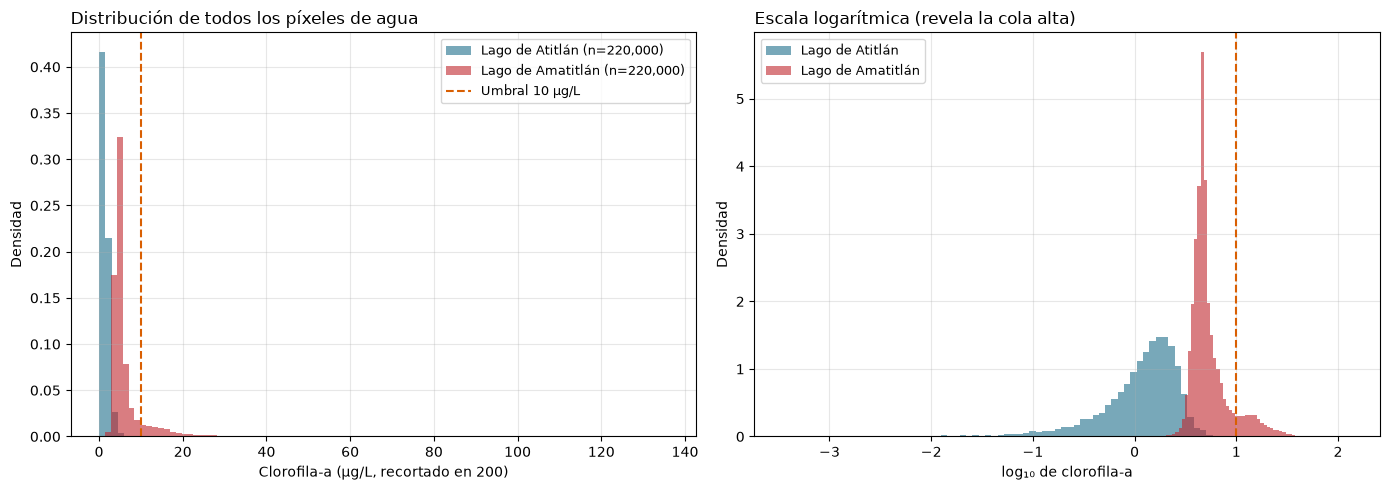

Mann-Whitney U: p = 0.00e+00
Mediana Atitlán 1.1 µg/L  |  mediana Amatitlán 4.7 µg/L


In [12]:
fig, ejes = plt.subplots(1, 2, figsize=(14, 5))

for lago in ["Atitlan", "Amatitlan"]:
    sub = pixeles[pixeles["lago"] == lago]["chl"].dropna()
    ejes[0].hist(sub.clip(upper=200), bins=90, alpha=0.6, density=True,
                 color=COLOR[lago], label=f"{config.NOMBRE_LARGO[lago]} (n={len(sub):,})")
ejes[0].axvline(ix.UMBRAL_ALTO_CHL, color="#d95f02", linestyle="--",
                label=f"Umbral {ix.UMBRAL_ALTO_CHL:.0f} µg/L")
ejes[0].set_xlabel("Clorofila-a (µg/L, recortado en 200)")
ejes[0].set_ylabel("Densidad")
ejes[0].set_title("Distribución de todos los píxeles de agua", loc="left")
ejes[0].legend(fontsize=9)

for lago in ["Atitlan", "Amatitlan"]:
    sub = pixeles[pixeles["lago"] == lago]["chl"].dropna()
    sub = sub[sub > 0]
    ejes[1].hist(np.log10(sub), bins=90, alpha=0.6, density=True,
                 color=COLOR[lago], label=config.NOMBRE_LARGO[lago])
ejes[1].axvline(np.log10(ix.UMBRAL_ALTO_CHL), color="#d95f02", linestyle="--")
ejes[1].set_xlabel("log₁₀ de clorofila-a")
ejes[1].set_ylabel("Densidad")
ejes[1].set_title("Escala logarítmica (revela la cola alta)", loc="left")
ejes[1].legend(fontsize=9)

for eje in ejes:
    eje.grid(alpha=0.3)
fig.tight_layout()
plt.show()

# Prueba formal de que las dos distribuciones son distintas.
a = pixeles[pixeles["lago"] == "Atitlan"]["chl"].dropna()
b = pixeles[pixeles["lago"] == "Amatitlan"]["chl"].dropna()
u, p = stats.mannwhitneyu(a, b, alternative="two-sided")
print(f"Mann-Whitney U: p = {p:.2e}")
print(f"Mediana Atitlán {a.median():.1f} µg/L  |  mediana Amatitlán {b.median():.1f} µg/L")

### Lectura de la comparación

Los números dejan poco margen de duda:

| | Atitlán | Amatitlán |
|---|---|---|
| Clorofila-a media del período | 1.24 µg/L | **6.29 µg/L** |
| Mediana por píxel | 1.1 µg/L | 4.7 µg/L |
| Rango entre fechas | 0.59 – 2.12 | 4.29 – **11.49** |
| Superficie media sobre 10 µg/L | 0.04 % | **10.80 %** |
| Superficie máxima sobre 10 µg/L | 0.14 % | **53.39 %** |
| Escenas mesotróficas o peor | 0 de 11 | **11 de 11** |
| Escenas eutróficas | 0 de 11 | 2 de 11 |
| Superficie del lago | 122 km² | 14.7 km² |

**Intensidad:** Amatitlán mantiene en promedio 5.1 veces la concentración de Atitlán, en un
espejo de agua 8.3 veces más pequeño. La prueba de Mann-Whitney sobre los píxeles confirma que
las dos distribuciones son distintas con p prácticamente nulo, aunque con cientos de miles de
píxeles eso era esperable; lo relevante es el tamaño de la diferencia, no su significancia.

**Frecuencia:** aquí el contraste es todavía más marcado que en intensidad. Amatitlán está en
condición mesotrófica o peor en **las 11 fechas observadas**, sin una sola excepción. Atitlán no
alcanza esa condición **en ninguna**. No se trata de que un lago tenga episodios peores: son dos
regímenes distintos.

**Variabilidad:** los dos lagos tienen un coeficiente de variación parecido (0.41 en Atitlán,
0.38 en Amatitlán), es decir, ambos fluctúan en proporción similar respecto a su propio nivel.
Lo que cambia es el nivel base sobre el que fluctúan.

**Un matiz sobre los picos absolutos:** el máximo puntual más alto de todo el estudio es de
Atitlán (135.9 µg/L el 17 de julio de 2025), por encima del máximo de Amatitlán (130.1 µg/L).
Pero son fenómenos distintos: en Atitlán es un puñado de píxeles aislados sobre un lago
oligotrófico —probablemente una embarcación, una mancha de sedimento tras una lluvia o un
artefacto de orilla— mientras que en Amatitlán el máximo viene acompañado de un percentil 99 de
51 µg/L, es decir, de toda una cola de la distribución elevada. Un máximo aislado no es una
floración; por eso el análisis se apoya en la media, la mediana y el percentil 90, y no en el
máximo.

### 7.4 Contexto físico de los dos lagos

Las diferencias que muestran los números tienen una explicación en la forma y el entorno de
cada lago. Estos son datos publicados, no medidos por nosotros, y sirven para interpretar lo
que vimos.

| | **Atitlán** | **Amatitlán** |
|---|---|---|
| Superficie | ~130 km² | ~15 km² |
| Profundidad media | ~180 m | ~18 m |
| Profundidad máxima | ~340 m | ~33 m |
| Altitud | ~1,560 m | ~1,190 m |
| Origen | Caldera volcánica | Cuenca volcánica somera |
| Cuenca | ~541 km² | ~381 km² |
| Población en la cuenca | ~150,000 hab. | >1.5 millones (área metropolitana) |
| Principal entrada | Ríos estacionales de la caldera | Río Villalobos |
| Salida | Sin salida superficial (endorreico) | Río Michatoya |

Cuatro factores explican por qué Amatitlán está en peor condición:

1. **Profundidad.** Atitlán tiene diez veces más profundidad media. El mismo nutriente repartido
   en una columna de 180 m produce mucha menos concentración que en una de 18 m. Además un lago
   profundo estratifica y guarda nutriente lejos de la superficie iluminada.
2. **Presión urbana.** La cuenca de Amatitlán recibe la descarga del área metropolitana de la
   capital, con más de un millón y medio de habitantes; el río Villalobos llega cargado de aguas
   residuales sin tratamiento suficiente. La cuenca de Atitlán tiene un orden de magnitud menos
   de población.
3. **Tiempo de residencia y recambio.** Amatitlán drena por el Michatoya, pero su volumen es
   pequeño frente a lo que entra; Atitlán es endorreico pero su volumen es enorme, así que la
   carga se diluye muchísimo más.
4. **Temperatura.** Amatitlán está unos 370 m más bajo, lo que se traduce en agua más cálida
   —del orden de 2 a 3 °C— y la cianobacteria se reproduce más rápido con más calor.

La comparación honesta no es "un lago está mal y el otro bien", sino que son sistemas de
escalas distintas: Amatitlán es un lago pequeño y somero recibiendo la carga de una capital,
mientras Atitlán es un lago grande y profundo con una carga proporcionalmente mucho menor —lo
que no lo hace inmune, como muestran sus propios episodios.

### Interpretación de las correlaciones

**A nivel de píxel, los tres índices se mueven como manda la física.** El NDVI sube con la
clorofila (ρ = +0.71 en Atitlán, +0.66 en Amatitlán) y el NDWI baja (ρ = −0.70 y −0.47). Como se
explicó arriba, una parte de eso está garantizada por construcción: NDVI y NDCI comparten la
banda roja. Lo que sí es informativo es comparar los dos lagos.

**La diferencia que importa está en el FAI.** El índice de material flotante correlaciona con la
clorofila a ρ = **+0.844 en Amatitlán** frente a ρ = **+0.304 en Atitlán**. Esa brecha dice algo
concreto: en Amatitlán la carga de clorofila viene acompañada de material que flota en la
superficie —natas, acumulaciones visibles—, mientras que en Atitlán la poca clorofila que hay
está dispersa en la columna de agua y no forma capa. Es la diferencia entre un lago con
floraciones y un lago con algas.

**A nivel de escena aparece un contraste revelador.** En Atitlán el NDWI predice la clorofila
casi perfectamente (r = −0.955, p < 0.0001): cuando el lago se carga un poco, su firma óptica de
agua limpia se degrada de forma proporcional. En Amatitlán esa relación **se pierde**
(r = −0.348, p = 0.294, no significativa).

La explicación es que en Atitlán la clorofila es prácticamente lo único que altera el color del
agua, así que cualquier índice óptico la sigue. En Amatitlán compiten otros factores —sedimento
en suspensión que arrastra el Villalobos, materia orgánica disuelta, menor profundidad— que
también modifican la reflectancia y rompen la relación limpia entre NDWI y clorofila.

**Significado ambiental.** Para Atitlán, la conclusión práctica es que el NDWI serviría como
señal de alerta temprana barata: basta vigilar que no baje. Para Amatitlán no sirve, y hay que
medir la clorofila directamente con el borde rojo, porque el agua ya está ópticamente
"contaminada" por más de una cosa a la vez.